Import Libraries

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scaling
from sklearn.preprocessing import StandardScaler

# K-Means
from sklearn.cluster import KMeans

# PCA
from sklearn.decomposition import PCA

Load Dataset

In [3]:
df = pd.read_csv("Mall_Customers.csv")

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


Explore Dataset (EDA)

Check Dataset Shape

In [4]:
print(df.shape)

(200, 5)


Check Column Names

In [5]:
print(df.columns)

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


Check Missing Values

In [6]:
print(df.isnull().sum())

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


**Visualize Data**

Age Distribution

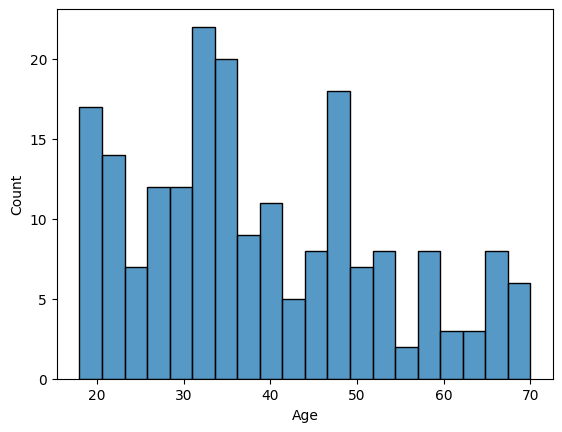

In [7]:
sns.histplot(df['Age'], bins=20)
plt.show()

Income vs Spending Score

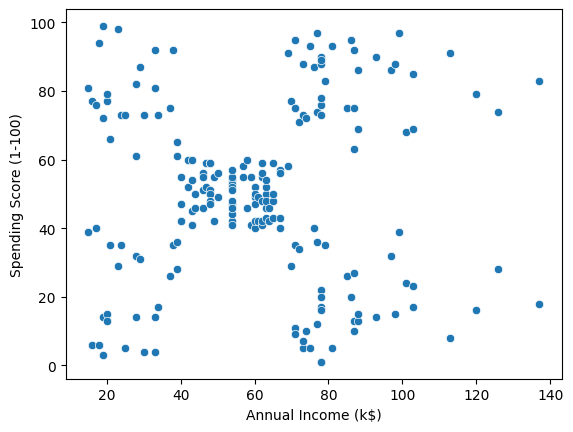

In [8]:
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.show()

Select Important Features

In [9]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

**Scale the Data**

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**Find Best Number of Clusters**

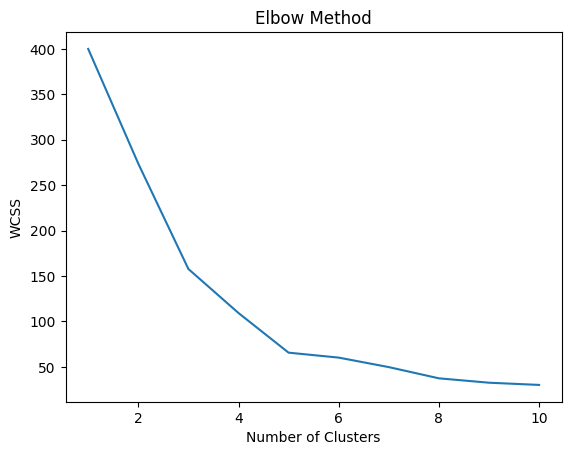

In [11]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

**Apply K-Means Clustering**

In [12]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

**Visualize Clusters**

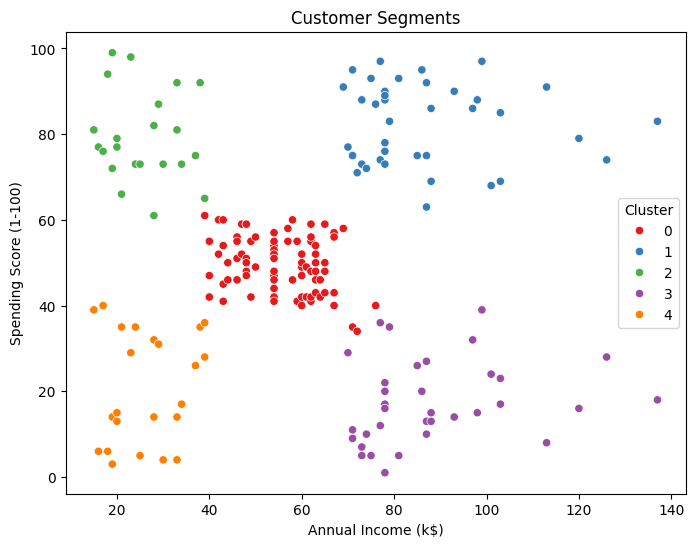

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1'
)

plt.title("Customer Segments")
plt.show()

**PCA for Dimensionality Reduction**

In [14]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

Plot PCA Clusters

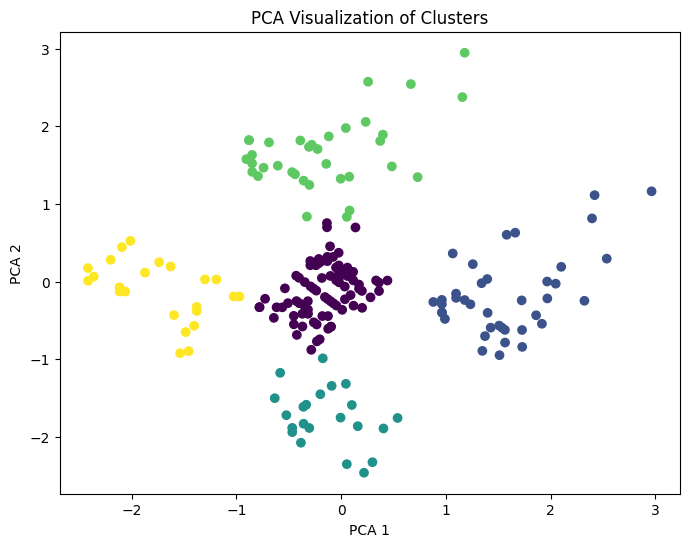

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df['Cluster']
)

plt.title("PCA Visualization of Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()